<a href="https://colab.research.google.com/github/kutayeroglu/biomimetic-training/blob/main/interpret_results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import pandas as pd
import ast
import os

# Define the path to your results
file_path = "/content/drive/MyDrive/colab_results/biomimetic_training/evaluation_results.csv"

if not os.path.exists(file_path):
    print(f"Error: File not found at {file_path}")
else:
    # 1. Load the data
    df = pd.read_csv(file_path, index_col=0)

    # 2. Function to parse the string "[shape, other, texture]" into a list of integers
    def parse_results(val):
        return ast.literal_eval(val)

    # 3. Focus on the baseline (no ablation) for both ranking methods
    baseline_cols = [col for col in df.columns if "ablation_0" in col]

    print(f"Verifying baseline claims for: {baseline_cols}\n")

    for col in baseline_cols:
        # Convert strings to lists
        parsed_data = df[col].apply(parse_results)

        # Calculate totals
        total_shape = sum([x[0] for x in parsed_data])
        total_other = sum([x[1] for x in parsed_data])
        total_texture = sum([x[2] for x in parsed_data])
        total_images = total_shape + total_other + total_texture

        # Calculate bias metrics
        # Shape bias is defined as shape / (shape + texture)
        denominator = total_shape + total_texture
        shape_bias = (total_shape / denominator) if denominator > 0 else 0
        texture_bias = (total_texture / denominator) if denominator > 0 else 0

        print(f"--- Results for {col} ---")
        print(f"Total Images Analyzed: {total_images}")
        print(f"Shape-consistent decisions: {total_shape}")
        print(f"Texture-consistent decisions: {total_texture}")
        print(f"Other/Incorrect decisions: {total_other}")
        print(f"Calculated Shape Bias: {shape_bias:.4f}")
        print(f"Calculated Texture Bias: {texture_bias:.4f}\n")

Verifying baseline claims for: ['color_standard_alexnet_ablation_0', 'fft_freq_standard_alexnet_ablation_0', 'color_reverse_standard_alexnet_ablation_0', 'fft_freq_reverse_standard_alexnet_ablation_0']

--- Results for color_standard_alexnet_ablation_0 ---
Total Images Analyzed: 1200
Shape-consistent decisions: 66
Texture-consistent decisions: 111
Other/Incorrect decisions: 1023
Calculated Shape Bias: 0.3729
Calculated Texture Bias: 0.6271

--- Results for fft_freq_standard_alexnet_ablation_0 ---
Total Images Analyzed: 1200
Shape-consistent decisions: 66
Texture-consistent decisions: 111
Other/Incorrect decisions: 1023
Calculated Shape Bias: 0.3729
Calculated Texture Bias: 0.6271

--- Results for color_reverse_standard_alexnet_ablation_0 ---
Total Images Analyzed: 1200
Shape-consistent decisions: 66
Texture-consistent decisions: 111
Other/Incorrect decisions: 1023
Calculated Shape Bias: 0.3729
Calculated Texture Bias: 0.6271

--- Results for fft_freq_reverse_standard_alexnet_ablation_0

In [3]:
df['color_standard_alexnet_ablation_48']

,color_standard_alexnet_ablation_48
knife,"[0, 70, 5]"
keyboard,"[0, 70, 5]"
elephant,"[0, 70, 5]"
bicycle,"[0, 70, 5]"
airplane,"[0, 70, 5]"
clock,"[0, 70, 5]"
oven,"[0, 70, 5]"
chair,"[0, 70, 5]"
bear,"[0, 70, 5]"
boat,"[0, 70, 5]"


In [4]:
!rm -rf biomimetic-training
!git clone https://github.com/kutayeroglu/biomimetic-training.git

Cloning into 'biomimetic-training'...
remote: Enumerating objects: 247, done.
remote: Counting objects: 100% (30/30), done.
remote: Compressing objects: 100% (23/23), done.
remote: Total 247 (delta 16), reused 20 (delta 7), pack-reused 217 (from 1)
Receiving objects: 100% (247/247), 2.50 MiB | 9.83 MiB/s, done.
Resolving deltas: 100% (126/126), done.


In [5]:
import sys
import os

# 1. Stay in /content
%cd /content

# 2. Add the root to sys.path so 'src' is findable inside the cloned folder
if "/content/biomimetic-training" not in sys.path:
    sys.path.append("/content/biomimetic-training")

# 3. Now the import should work
from src.eval.viz.plotting import load_and_parse_results

/content


/content/biomimetic-training/src/eval/viz/plotting.py:42: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  return df.applymap(parse_cell)


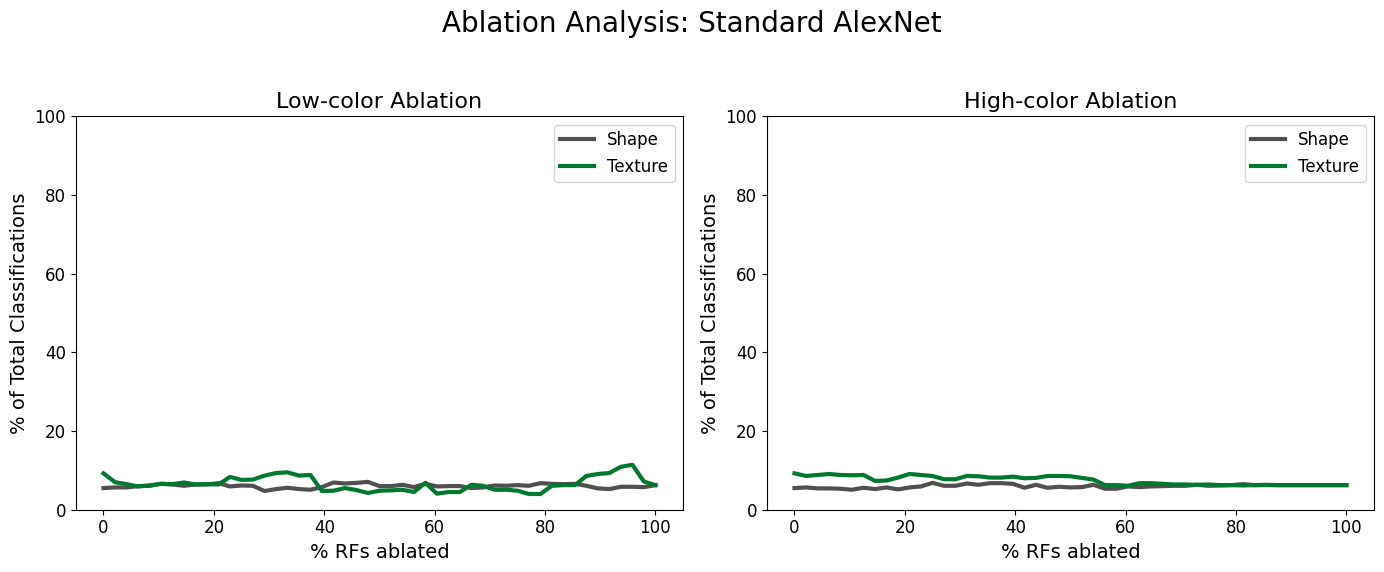

In [6]:
import os
from src.eval.viz.plotting import load_and_parse_results, plot_fig_1_top, plot_fig_1_down, plot_fig_2_right

if __name__ == "__main__":
    PATH = "/content/drive/MyDrive/colab_results/biomimetic_training/evaluation_results.csv"

    if os.path.exists(PATH):
        data = load_and_parse_results(PATH)

        # 'regimen_key' must match the string used in your CSV column names (e.g., 'standard_alexnet')
        reg_key = "standard_alexnet"
        reg_name = "Standard AlexNet"

        # plot_fig_1_top(data, reg_key, reg_name, "fig_1_top.png")
        # plot_fig_1_down(data, reg_key, reg_name, "fig_1_down.png")
        plot_fig_2_right (data, reg_key, reg_name, "fig_2de.png")
    else:
        print("Results file not found. Check your Drive path.")